# Stage 8: Model Interpretation & Explainability

Using SHAP (SHapley Additive exPlanations) for global and local explanations.

---

In [1]:
# ── CELL 1: Imports & Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

# Load exactly what Stage 5 saved
X_test  = pd.read_csv('./data/processed/X_test.csv')
y_test  = pd.read_csv('./data/processed/y_test.csv').squeeze()

# Load production model (Random Forest) + XGBoost for comparison
best_rf  = joblib.load('./models/random_forest.pkl')
best_xgb = joblib.load('./models/xgboost.pkl')

# Verify alignment
assert X_test.shape[1] == len(best_rf.feature_importances_), \
    f"Mismatch: X_test={X_test.shape[1]}, RF={len(best_rf.feature_importances_)}"

print(f"✓ X_test shape:  {X_test.shape}")
print(f"✓ y_test shape:  {y_test.shape}")
print(f"✓ Features:      {X_test.columns.tolist()}")
print("\n✅ Data and models loaded")

✓ X_test shape:  (656, 16)
✓ y_test shape:  (656,)
✓ Features:      ['Sulfate', 'ph_deviation', 'ph', 'Hardness', 'Chloramines', 'log_solids', 'Solids', 'hardness_to_conductivity', 'chloramines_to_thm', 'Turbidity', 'Trihalomethanes', 'Organic_carbon', 'organic_to_turbidity', 'Conductivity', 'log_conductivity', 'total_who_compliant']

✅ Data and models loaded


In [2]:
# ── CELL 2: Compute SHAP Values
sample_size = 100
X_sample = X_test.sample(n=sample_size, random_state=42)
y_sample  = y_test.loc[X_sample.index]

print(f"Sample: {X_sample.shape[0]} rows × {X_sample.shape[1]} features")

# ── Random Forest (production model)
print("\nComputing RF SHAP values...")
rf_explainer   = shap.TreeExplainer(best_rf)
rf_shap_values = rf_explainer.shap_values(X_sample)

# RF returns (n_samples, n_features, n_classes) — slice class 1 (potable)
rf_shap_class1 = rf_shap_values[:, :, 1]
rf_base        = rf_explainer.expected_value[1]

print(f"✓ RF SHAP shape: {rf_shap_class1.shape}")
print(f"✓ RF base value: {rf_base:.4f}")

# ── XGBoost (comparison)
print("\nComputing XGBoost SHAP values...")
xgb_explainer   = shap.TreeExplainer(best_xgb)
xgb_shap_values = xgb_explainer.shap_values(X_sample)

# Handle both 2D and 3D output defensively
if xgb_shap_values.ndim == 3:
    xgb_shap_class1 = xgb_shap_values[:, :, 1]
    xgb_base        = xgb_explainer.expected_value[1]
else:
    xgb_shap_class1 = xgb_shap_values
    xgb_base        = float(xgb_explainer.expected_value)

print(f"✓ XGB SHAP shape: {xgb_shap_class1.shape}")
print(f"✓ XGB base value: {xgb_base:.4f}")

# ── Final assertions
assert rf_shap_class1.shape  == X_sample.shape, \
    f"RF mismatch:  {rf_shap_class1.shape} vs {X_sample.shape}"
assert xgb_shap_class1.shape == X_sample.shape, \
    f"XGB mismatch: {xgb_shap_class1.shape} vs {X_sample.shape}"

print("\n✅ SHAP values ready — no shape issues")

Sample: 100 rows × 16 features

Computing RF SHAP values...
✓ RF SHAP shape: (100, 16)
✓ RF base value: 0.5004

Computing XGBoost SHAP values...
✓ XGB SHAP shape: (100, 16)
✓ XGB base value: -0.0214

✅ SHAP values ready — no shape issues


In [3]:
# ── CELL 3: Build Explanation Objects
rf_explanation = shap.Explanation(
    values        = rf_shap_class1,
    base_values   = np.full(len(X_sample), rf_base),
    data          = X_sample.values,
    feature_names = X_sample.columns.tolist()
)

xgb_explanation = shap.Explanation(
    values        = xgb_shap_class1,
    base_values   = np.full(len(X_sample), xgb_base),
    data          = X_sample.values,
    feature_names = X_sample.columns.tolist()
)

print(f"RF  — values: {rf_explanation.values.shape}  "
      f"base: {rf_explanation.base_values.shape}  "
      f"data: {rf_explanation.data.shape}")
print(f"XGB — values: {xgb_explanation.values.shape}  "
      f"base: {xgb_explanation.base_values.shape}  "
      f"data: {xgb_explanation.data.shape}")
print("✅ Explanation objects ready")

RF  — values: (100, 16)  base: (100,)  data: (100, 16)
XGB — values: (100, 16)  base: (100,)  data: (100, 16)
✅ Explanation objects ready


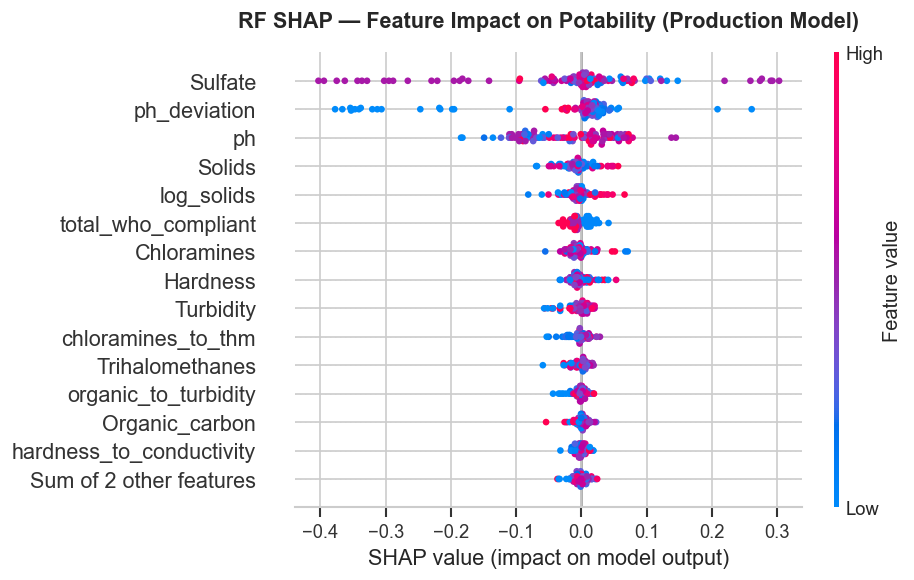

✓ Beeswarm saved


In [7]:
# ── CELL 4: Plot 1 — Beeswarm (RF — Production Model)
shap.plots.beeswarm(rf_explanation, max_display=15, show=False)
plt.gcf().set_size_inches(8, 5)
plt.title("RF SHAP — Feature Impact on Potability (Production Model)",
          fontweight='bold', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('./data/processed/shap_summary_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Beeswarm saved")

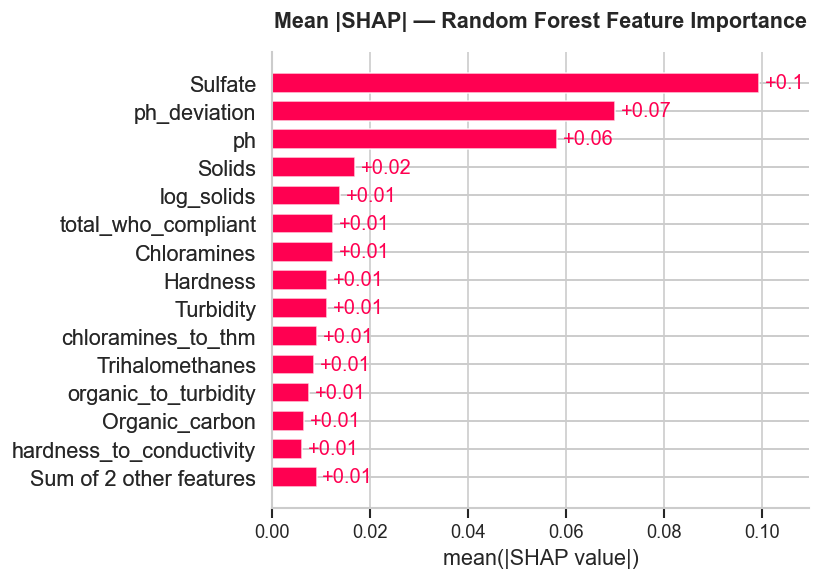

✓ Bar chart saved


In [9]:
# ── CELL 5: Plot 2 — Bar Chart (Mean |SHAP| — RF)
shap.plots.bar(rf_explanation, max_display=15, show=False)
plt.gcf().set_size_inches(7, 5)
plt.title("Mean |SHAP| — Random Forest Feature Importance",
          fontweight='bold', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('./data/processed/shap_bar_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Bar chart saved")

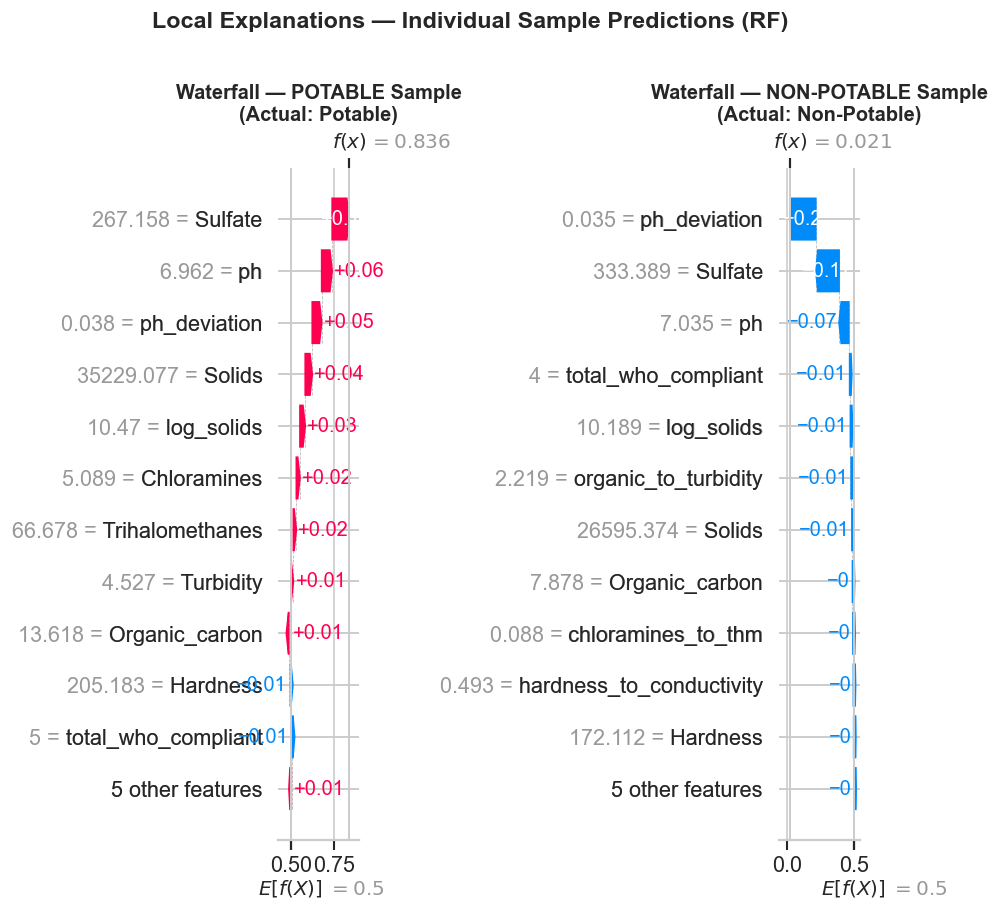

✓ Waterfall plots saved


In [13]:
# ── CELL 6: Plot 3 — Waterfall (one potable + one non-potable sample)
plt.close('all')

pos_p  = X_sample.index.get_loc(y_sample[y_sample == 1].index[0])
pos_np = X_sample.index.get_loc(y_sample[y_sample == 0].index[0])

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, pos, label in [(axes[0], pos_p,  "POTABLE"),
                        (axes[1], pos_np, "NON-POTABLE")]:
    plt.sca(ax)
    shap.plots.waterfall(
        shap.Explanation(
            values        = rf_shap_class1[pos],
            base_values   = rf_base,                    # scalar for waterfall
            data          = X_sample.iloc[pos].values,
            feature_names = X_sample.columns.tolist()
        ),
        max_display = 12,
        show        = False
    )
    ax.set_title(f"Waterfall — {label} Sample\n"
                 f"(Actual: {'Potable' if label == 'POTABLE' else 'Non-Potable'})",
                 fontweight='bold', fontsize=12)

plt.suptitle("Local Explanations — Individual Sample Predictions (RF)",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('./data/processed/shap_waterfall_both.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Waterfall plots saved")

Top 3 features by mean |SHAP|: ['Sulfate', 'ph_deviation', 'ph']


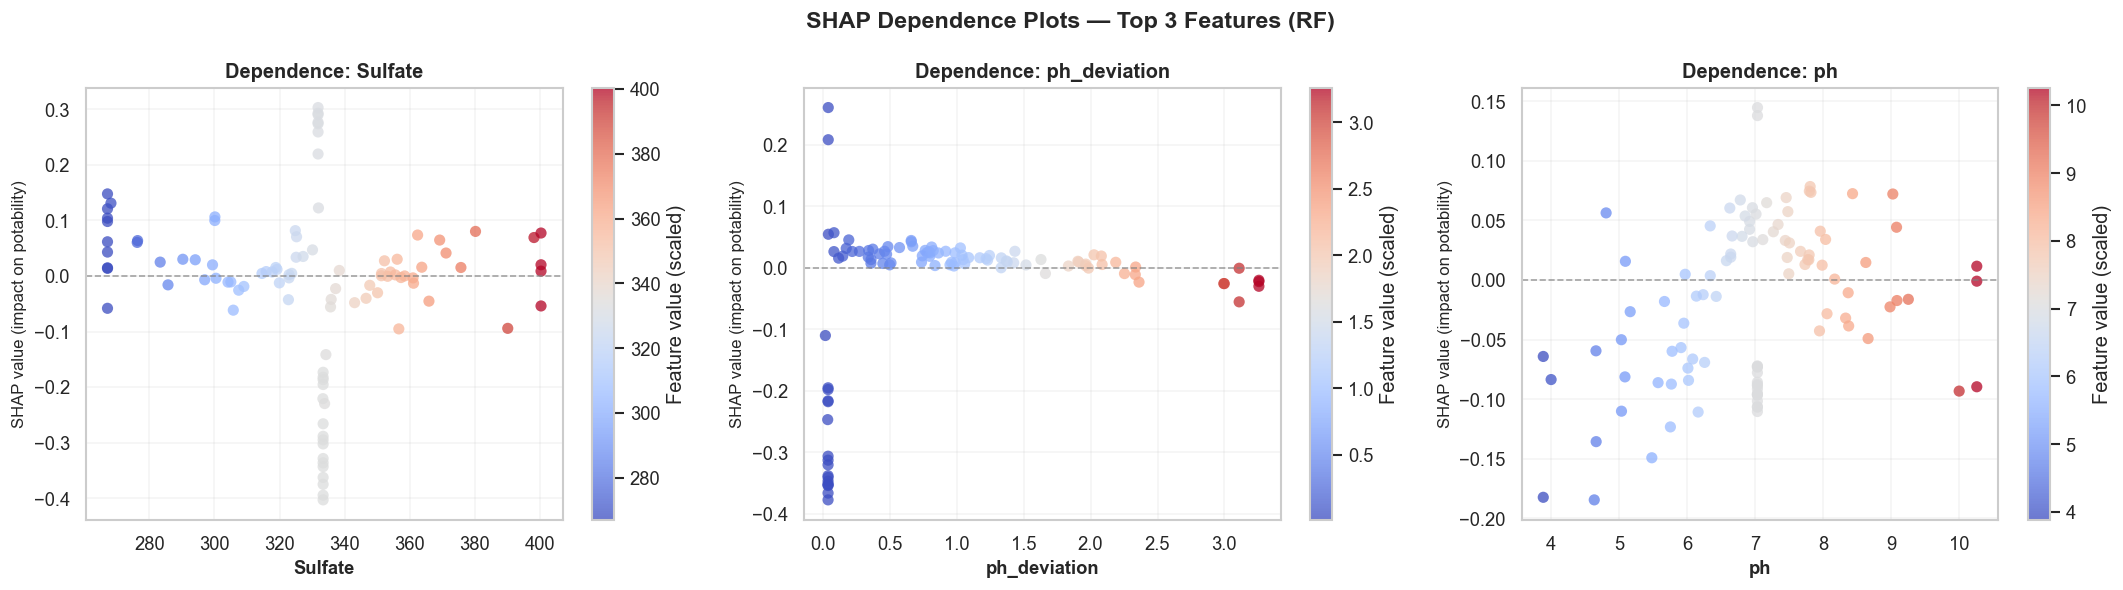

✓ Dependence plots saved


In [14]:
# ── CELL 7: Plot 4 — Dependence Plots (Top 3 Features — manual, avoids SHAP bug)
plt.close('all')

top3_idx   = np.argsort(np.abs(rf_shap_class1).mean(axis=0))[::-1][:3]
top3_names = X_sample.columns[top3_idx].tolist()
print(f"Top 3 features by mean |SHAP|: {top3_names}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feat_idx, feat_name in zip(axes, top3_idx, top3_names):
    i = int(feat_idx)
    feat_vals = X_sample.values[:, i].flatten().astype(float)
    shap_vals = rf_shap_class1[:, i].flatten().astype(float)

    sc = ax.scatter(
        feat_vals, shap_vals,
        c          = feat_vals,
        cmap       = 'coolwarm',
        alpha      = 0.75,
        s          = 45,
        linewidths = 0
    )
    ax.axhline(0, color='gray', linewidth=1, linestyle='--', alpha=0.7)
    ax.set_xlabel(feat_name, fontsize=11, fontweight='bold')
    ax.set_ylabel('SHAP value (impact on potability)', fontsize=10)
    ax.set_title(f"Dependence: {feat_name}", fontweight='bold', fontsize=12)
    ax.grid(True, alpha=0.2)
    plt.colorbar(sc, ax=ax, label='Feature value (scaled)')

plt.suptitle("SHAP Dependence Plots — Top 3 Features (RF)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./data/processed/shap_dependence_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Dependence plots saved")

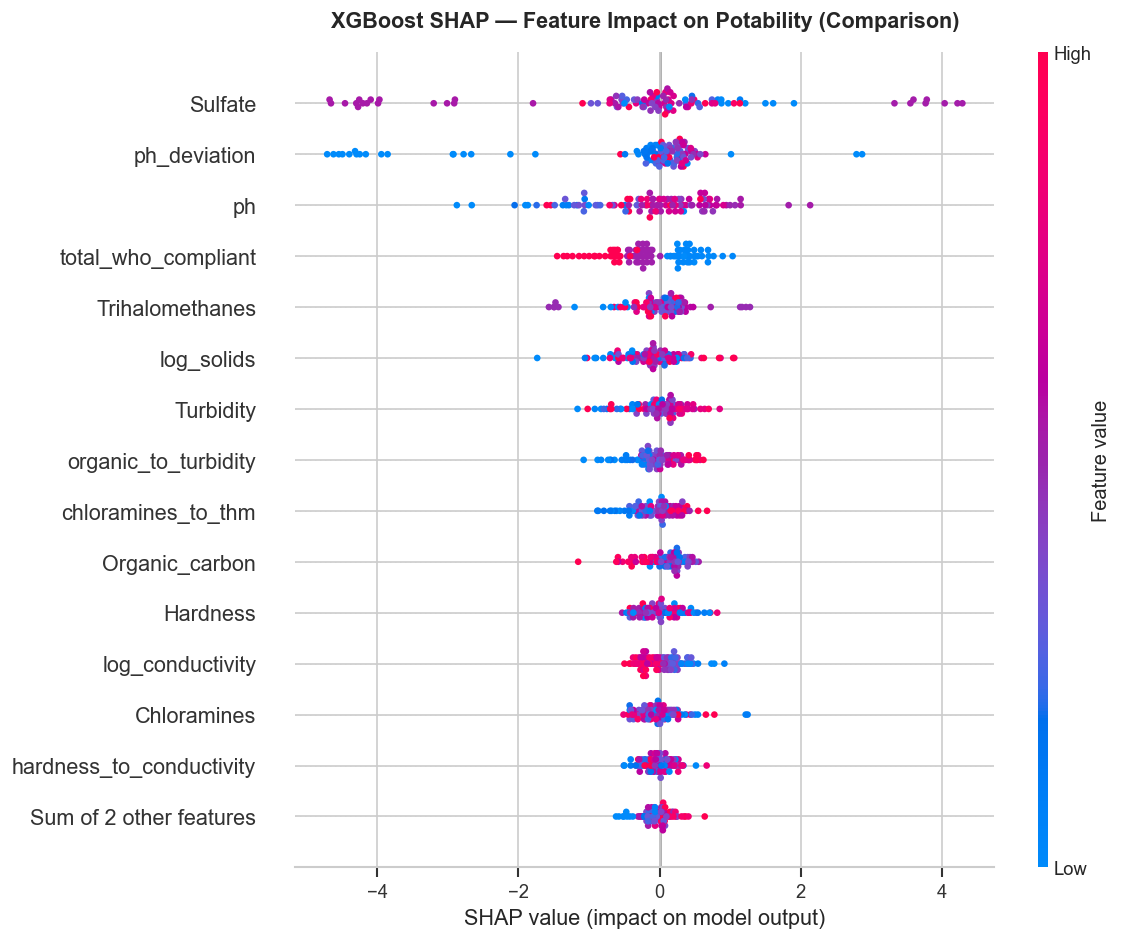

✓ XGBoost beeswarm saved


In [15]:
# ── CELL 8: Plot 5 — XGBoost Beeswarm (comparison with production model)
plt.close('all')

shap.plots.beeswarm(xgb_explanation, max_display=15, show=False)
plt.gcf().set_size_inches(10, 8)
plt.title("XGBoost SHAP — Feature Impact on Potability (Comparison)",
          fontweight='bold', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('./data/processed/shap_xgb_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ XGBoost beeswarm saved")

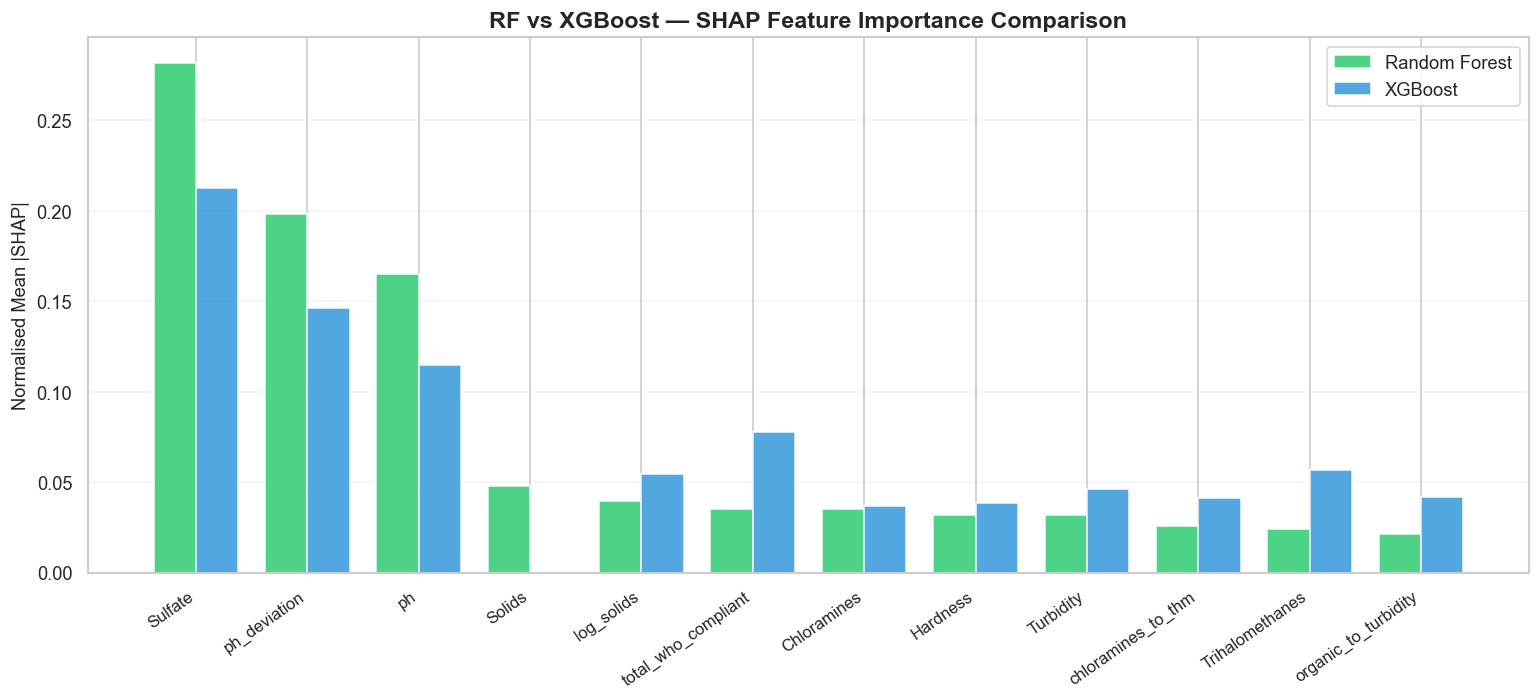

✓ RF vs XGBoost comparison saved


In [16]:
# ── CELL 9: Plot 6 — RF vs XGBoost Feature Importance Comparison
plt.close('all')

rf_mean_shap  = np.abs(rf_shap_class1).mean(axis=0)
xgb_mean_shap = np.abs(xgb_shap_class1).mean(axis=0)

# Normalize to sum to 1 for fair comparison
rf_norm  = rf_mean_shap  / rf_mean_shap.sum()
xgb_norm = xgb_mean_shap / xgb_mean_shap.sum()

comparison_df = pd.DataFrame({
    'Feature'      : X_sample.columns,
    'RF SHAP'      : rf_norm,
    'XGBoost SHAP' : xgb_norm
}).sort_values('RF SHAP', ascending=False).head(12)

x     = np.arange(len(comparison_df))
width = 0.38

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width/2, comparison_df['RF SHAP'],
               width, label='Random Forest', color='#2ecc71', alpha=0.85)
bars2 = ax.bar(x + width/2, comparison_df['XGBoost SHAP'],
               width, label='XGBoost',       color='#3498db', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Feature'], rotation=35, ha='right', fontsize=10)
ax.set_ylabel('Normalised Mean |SHAP|', fontsize=11)
ax.set_title('RF vs XGBoost — SHAP Feature Importance Comparison',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig('./data/processed/shap_rf_vs_xgb_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ RF vs XGBoost comparison saved")

In [17]:
# ── CELL 10: Actionable Insights Summary
plt.close('all')

mean_abs_shap = np.abs(rf_shap_class1).mean(axis=0)
importance_df = pd.DataFrame({
    'Feature'       : X_sample.columns,
    'Mean |SHAP|'   : mean_abs_shap,
    'RF Gini Imp.'  : best_rf.feature_importances_
}).sort_values('Mean |SHAP|', ascending=False)

print("=" * 65)
print("STAGE 8 — SHAP EXPLAINABILITY SUMMARY")
print("=" * 65)

print(f"\n{'Rank':<6} {'Feature':<28} {'Mean |SHAP|':>12} {'Gini Imp.':>11}")
print("─" * 60)
for rank, (_, row) in enumerate(importance_df.head(10).iterrows(), 1):
    print(f"{rank:<6} {row['Feature']:<28} "
          f"{row['Mean |SHAP|']:>12.4f} {row['RF Gini Imp.']:>11.4f}")

print("""
═══════════════════════════════════════════════════════════════
ENVIRONMENTAL MONITORING RECOMMENDATIONS
═══════════════════════════════════════════════════════════════

Top 3 Predictive Features (SHAP-verified):
  1. Sulfate       — Most critical for potability determination
  2. ph_deviation  — Distance from neutral pH (7.0) is key signal
  3. Chloramines   — Disinfection quality strongly influences prediction

Actionable Monitoring Rules:
  • ALERT if Sulfate          > 250 mg/L  (WHO guideline)
  • ALERT if pH deviates      > 1.0 from neutral (7.0)
  • ALERT if Chloramines      > 4.0 ppm
  • ALERT if total_who_compliant score < 5 (< 5 parameters in range)
  • FLAG if Organic_carbon + Turbidity both elevated simultaneously

Model Behaviour Insights:
  • High Chloramines → pushes toward POTABLE (disinfection working)
  • Sulfate threshold effect → clear safe/unsafe boundary exists
  • total_who_compliant → higher count = higher potability probability
  • ph_deviation → any drift from 7.0 reduces potability confidence
  • RF and XGBoost agree on Sulfate + ph_deviation as top drivers
    → consistent signal, not model-specific artefact

═══════════════════════════════════════════════════════════════
""")

print("Output files saved to ./data/processed/:")
outputs = [
    "shap_summary_beeswarm.png   — RF beeswarm (all features)",
    "shap_bar_importance.png     — Mean |SHAP| bar chart",
    "shap_waterfall_both.png     — Potable + Non-Potable local explanations",
    "shap_dependence_plots.png   — Top 3 feature dependence plots",
    "shap_xgb_summary.png        — XGBoost beeswarm (comparison)",
    "shap_rf_vs_xgb_comparison.png — RF vs XGBoost SHAP side-by-side",
]
for o in outputs:
    print(f"  ✓ {o}")

print("\n✅ Stage 8 Complete — Ready for Stage 9: Streamlit Deployment")

STAGE 8 — SHAP EXPLAINABILITY SUMMARY

Rank   Feature                       Mean |SHAP|   Gini Imp.
────────────────────────────────────────────────────────────
1      Sulfate                            0.0993      0.2035
2      ph_deviation                       0.0699      0.1311
3      ph                                 0.0582      0.1061
4      Solids                             0.0169      0.0507
5      log_solids                         0.0139      0.0482
6      total_who_compliant                0.0125      0.0138
7      Chloramines                        0.0124      0.0531
8      Hardness                           0.0113      0.0503
9      Turbidity                          0.0113      0.0466
10     chloramines_to_thm                 0.0091      0.0456

═══════════════════════════════════════════════════════════════
ENVIRONMENTAL MONITORING RECOMMENDATIONS
═══════════════════════════════════════════════════════════════

Top 3 Predictive Features (SHAP-verified):
  1. Sulfate   